![alt text](<Untitled design (1)-1.png>)


# Machine Learning Model for Loan Approval

### FinTech Innovations — Data-Driven Loan Risk and Approval Analysis


## Overview

This project develops a machine learning model to predict loan approval for FinTech Innovations. Three classification models were compared, and a Random Forest model was tuned using GridSearchCV. The tuned model achieved 93.23% accuracy, 89.23% precision, 81.49% recall, 85.18% F1-score, and 97.81% ROC-AUC on the test data. The model produced 94 false positives and 177 false negatives, resulting in an estimated business cost of $6.116 million under the case assumptions. The analysis also identified LoanToIncomeRatio, TotalDebtToIncomeRatio, MonthlyIncome, and AnnualIncome as important features. These results show that machine learning can support the loan approval process, but further validation using real repayment and default data is needed before deployment.


## Business Understanding

FinTech Innovations currently relies heavily on manual loan reviews. Loan officers assess applicants using financial and personal information before making approval decisions. While this process allows human judgment, it can be slow and may result in inconsistent decisions between applicants.

A machine learning model could help standardize the initial screening process and provide faster, data-driven support to loan officers. The model would not necessarily replace human review, but could help identify applications that require further assessment.

### Key Stakeholders

The main stakeholders include:

* **Loan officers:** Need consistent and useful predictions to support their decisions.
* **Management:** Needs to reduce financial losses while improving the efficiency of the loan approval process.
* **Customers:** Need fair and timely decisions when applying for loans.
* **Risk analysts:** Need a model that performs reliably and can be monitored for errors and bias.
* **Regulators:** Require decisions to be explainable and applied fairly.

### Business Impact of Model Errors

The two major types of classification errors have different financial consequences.

A **false positive** occurs when the model predicts that an applicant should be approved when the applicant is actually associated with a bad loan outcome. The estimated average loss from this type of error is **$50,000**.

A **false negative** occurs when the model predicts that an applicant should not be approved even though the applicant is creditworthy. The estimated missed profit from this error is **$8,000**.

Therefore, the model should not be evaluated using accuracy alone. The financial cost of different errors must also be considered.

### Choice of Classification

A **classification approach** was selected because the business problem involves making an approval-related decision. The model can classify applications into categories such as approval or non-approval and can then be evaluated using metrics such as precision, recall, F1-score, and ROC-AUC.

Classification also allows the confusion matrix to show the number of false positives and false negatives, which can then be connected directly to the estimated financial costs.


### Modeling Goals and Success Criteria

The main goal is to develop a classification model that can support loan approval decisions while limiting costly prediction errors.

The following metrics will be used:

* **Accuracy:** Measures the overall proportion of correct predictions.
* **Precision:** Measures how many applicants predicted as approved are actually in the positive class.
* **Recall:** Measures how well the model identifies applicants belonging to the positive class.
* **F1-score:** Provides a balance between precision and recall.
* **ROC-AUC:** Measures how well the model separates the two classes across different classification thresholds.

Because false positives and false negatives have different financial consequences, a **custom business-cost calculation** will also be used. This will estimate the financial impact of the model's false positives and false negatives using the provided values of **$50,000** and **$8,000**.

### Baseline

A simple baseline will be established using the majority class. This provides a reference point for determining whether the machine learning models provide meaningful improvement over a basic prediction strategy.

The final model will be considered successful if it performs better than the baseline while maintaining a reasonable balance between precision and recall and reducing the financial impact of costly classification errors.


## Data Understanding



The dataset contains 20,000 loan applications and 35 features covering applicants' demographic, financial, employment, credit, and loan information.

### Basic Data Characteristics

The dataset contains both numerical and categorical variables. There are 28 numerical columns and 7 categorical columns. `LoanApproved` is the target variable for this classification problem, with 0 representing a loan that was not approved and 1 representing an approved loan.

The target is imbalanced, with 15,220 applications (76.1%) not approved and 4,780 applications (23.9%) approved.

### Feature Types

**Numerical features** include `Age`, `CreditScore`, `Experience`, `LoanAmount`, `LoanDuration`, `NumberOfDependents`, `MonthlyDebtPayments`, `DebtToIncomeRatio`, `SavingsAccountBalance`, `MonthlyIncome`, `NetWorth`, and other financial variables.

**Categorical features** include `EmploymentStatus`, `EducationLevel`, `MaritalStatus`, `HomeOwnershipStatus`, `BankruptcyHistory`, and `LoanPurpose`.

`EducationLevel` can also be treated as an ordinal feature because its categories represent different levels of education. However, it will be handled as a categorical variable in the preprocessing pipeline.

### Distributions and Relationships

The exploratory analysis examined the distributions of important numerical features such as `LoanAmount` and `CreditScore`, as well as the distribution of the target variable.

Relationships between features were investigated using approval comparisons, a correlation matrix, and a pair plot. Loan approval was also compared across employment status, education level, and loan purpose to identify differences between applicant groups.

A statistical test comparing the credit scores of approved and non-approved applicants produced a t-statistic of 20.29 and a p-value of approximately 1.38 × 10⁻⁹⁰. This provides strong statistical evidence that the average credit scores differ between the two groups.

### Data Quality Issues

Three columns contain missing values: `EducationLevel` has 901 missing values, `MaritalStatus` has 1,331 missing values, and `SavingsAccountBalance` has 572 missing values. These missing values need to be handled before modeling.

`AnnualIncome` is stored as an object rather than a numerical variable because the values contain dollar signs and commas. It will need to be converted to a numerical format.

No duplicate rows were found.

### Feature Preprocessing and Engineering

Numerical features may require scaling because they have different ranges. Categorical features require encoding so that machine learning models can use them. Missing numerical values will be imputed, while missing categorical values will also be handled during preprocessing.

Potential feature engineering opportunities include creating financial ratios or other indicators from existing income, debt, loan, and asset variables. Care will also be taken to avoid data leakage by ensuring that information used to create predictions would realistically be available when a loan approval decision is made.


In [1]:
# Imports
# Import libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import tools for data preparation and modeling
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Import classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

c:\Users\User\anaconda3\envs\ml-env\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\User\anaconda3\envs\ml-env\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# EDA Code Here - Create New Cells As Needed
# Load the loan dataset
df = pd.read_csv("financial_loan_data.csv")

# Display the first five rows
df.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [3]:
# Check the number of rows and columns
print("Dataset shape:", df.shape)

Dataset shape: (20000, 35)


In [4]:
# Check the data types and non-null values for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

In [5]:
# Check the number of missing values in each column
missing_values = df.isnull().sum()

# Display only columns with missing values
missing_values[missing_values > 0]

EducationLevel            901
MaritalStatus            1331
SavingsAccountBalance     572
dtype: int64

In [6]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [7]:
# Display summary statistics for numerical columns
df.describe()

,Age,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,0.993000,...,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780
std,11.622713,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,0.986965,...,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262
min,18.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,0.000000,...,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,0.000000,...,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,40.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,1.000000,...,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,48.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,2.000000,...,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000
max,80.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,7.000000,...,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000


In [8]:
# Check the unique values in categorical columns
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts(dropna=False))


AnnualIncome:
AnnualIncome
$15,000.00     584
$300,000.00     26
$68,064.00       4
$24,627.00       4
$36,604.00       4
              ... 
$48,316.00       1
$50,463.00       1
$25,001.00       1
$22,593.00       1
$53,227.00       1
Name: count, Length: 17516, dtype: int64

EmploymentStatus:
EmploymentStatus
Employed         17036
Self-Employed     1573
Unemployed        1391
Name: count, dtype: int64

EducationLevel:
EducationLevel
Bachelor       5804
High School    5592
Associate      3850
Master         2933
Doctorate       920
NaN             901
Name: count, dtype: int64

MaritalStatus:
MaritalStatus
Married     9370
Single      5665
Divorced    2704
NaN         1331
Widowed      930
Name: count, dtype: int64

HomeOwnershipStatus:
HomeOwnershipStatus
Mortgage    7939
Rent        6087
Own         3938
Other       2036
Name: count, dtype: int64

BankruptcyHistory:
BankruptcyHistory
No     18952
Yes     1048
Name: count, dtype: int64

LoanPurpose:
LoanPurpose
Home                

In [9]:
# Check the distribution of the target variable
print(df["LoanApproved"].value_counts())
print("\nProportions:")
print(df["LoanApproved"].value_counts(normalize=True))


LoanApproved
0    15220
1     4780
Name: count, dtype: int64

Proportions:
LoanApproved
0    0.761
1    0.239
Name: proportion, dtype: float64


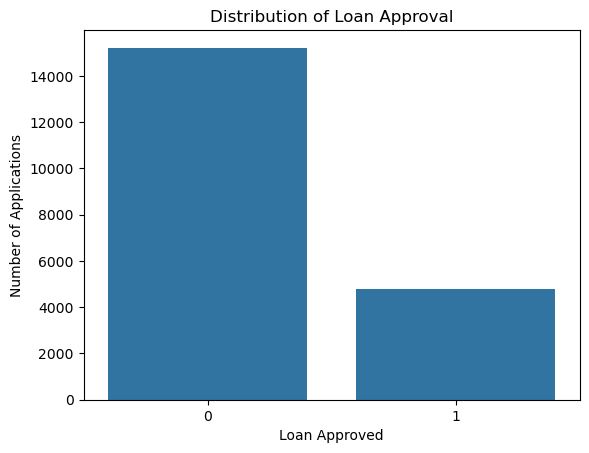

In [10]:
# Visualize the distribution of loan approvals
sns.countplot(x="LoanApproved", data=df)

plt.title("Distribution of Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Number of Applications")
plt.show()

### Loan Approval Distribution

The target variable is imbalanced. Most loan applications were not approved, while a smaller proportion were approved. This imbalance should be considered during model training and evaluation because accuracy alone may not give a complete picture of model performance.


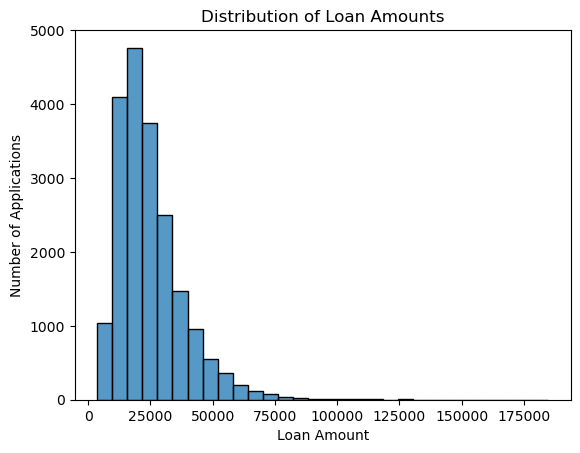

In [11]:
# Visualize the distribution of loan amounts
sns.histplot(df["LoanAmount"], bins=30)

plt.title("Distribution of Loan Amounts")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Applications")
plt.show()

### Loan Amount Distribution

This visualization shows how loan amounts are distributed across the applications. It helps identify the typical loan amounts and whether there are unusually high or low values that may need attention during modeling.


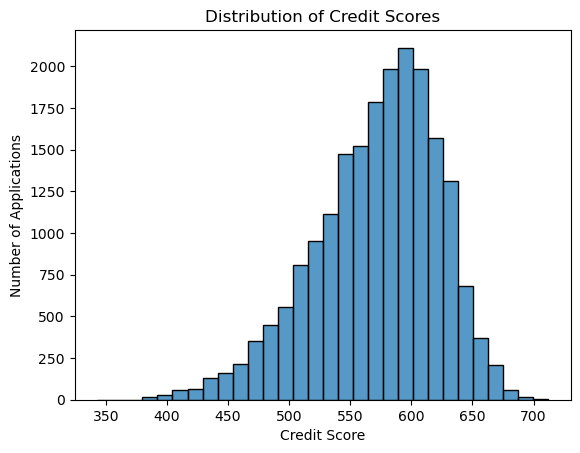

In [12]:
# Visualize the distribution of credit scores
sns.histplot(df["CreditScore"], bins=30)

plt.title("Distribution of Credit Scores")
plt.xlabel("Credit Score")
plt.ylabel("Number of Applications")
plt.show()

### Credit Score Distribution

This visualization shows the distribution of applicants' credit scores. Credit score is an important financial characteristic that may be associated with loan approval decisions.


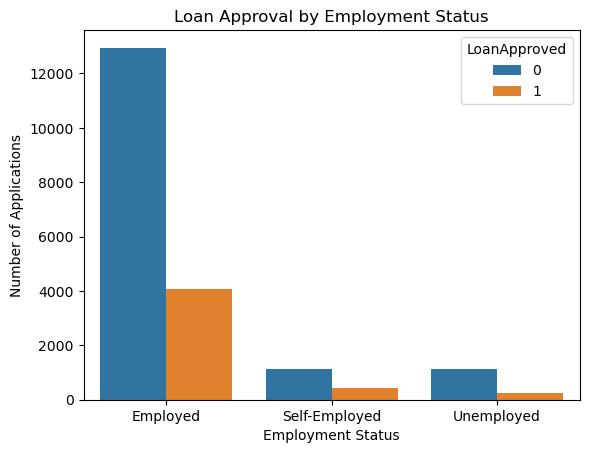

In [13]:
# Compare loan approval across employment status
sns.countplot(x="EmploymentStatus", hue="LoanApproved", data=df)

plt.title("Loan Approval by Employment Status")
plt.xlabel("Employment Status")
plt.ylabel("Number of Applications")
plt.show()

### Loan Approval by Employment Status

This visualization compares loan approval outcomes across different employment statuses. It helps identify whether approval patterns vary between employed, self-employed, and unemployed applicants.


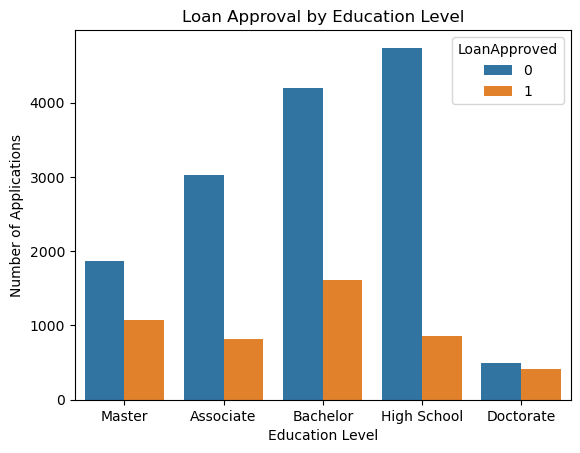

In [14]:
# Compare loan approval across education levels
sns.countplot(x="EducationLevel", hue="LoanApproved", data=df)

plt.title("Loan Approval by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Number of Applications")
plt.show()

### Loan Approval by Education Level

This visualization compares loan approval outcomes across education levels. It helps examine whether approval patterns differ among applicants with different levels of education.


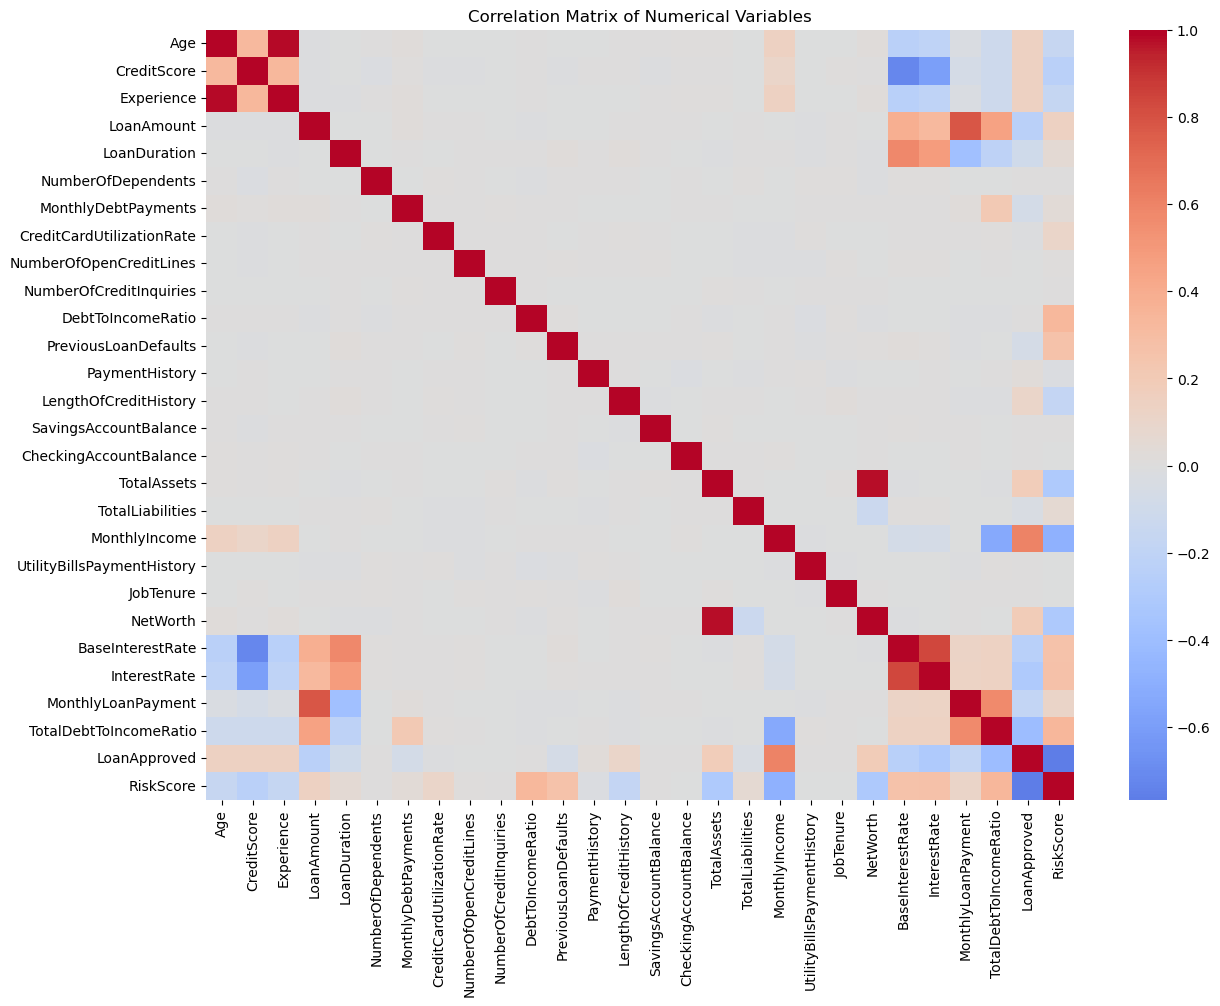

In [15]:
# Create a correlation matrix for numerical variables
correlation_matrix = df.select_dtypes(include="number").corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0)

plt.title("Correlation Matrix of Numerical Variables")
plt.show()

### Correlation Matrix

The correlation matrix shows the relationships between numerical variables. Strong correlations can help identify variables that may provide useful information for predicting loan approval and relationships that may need to be considered during modeling.


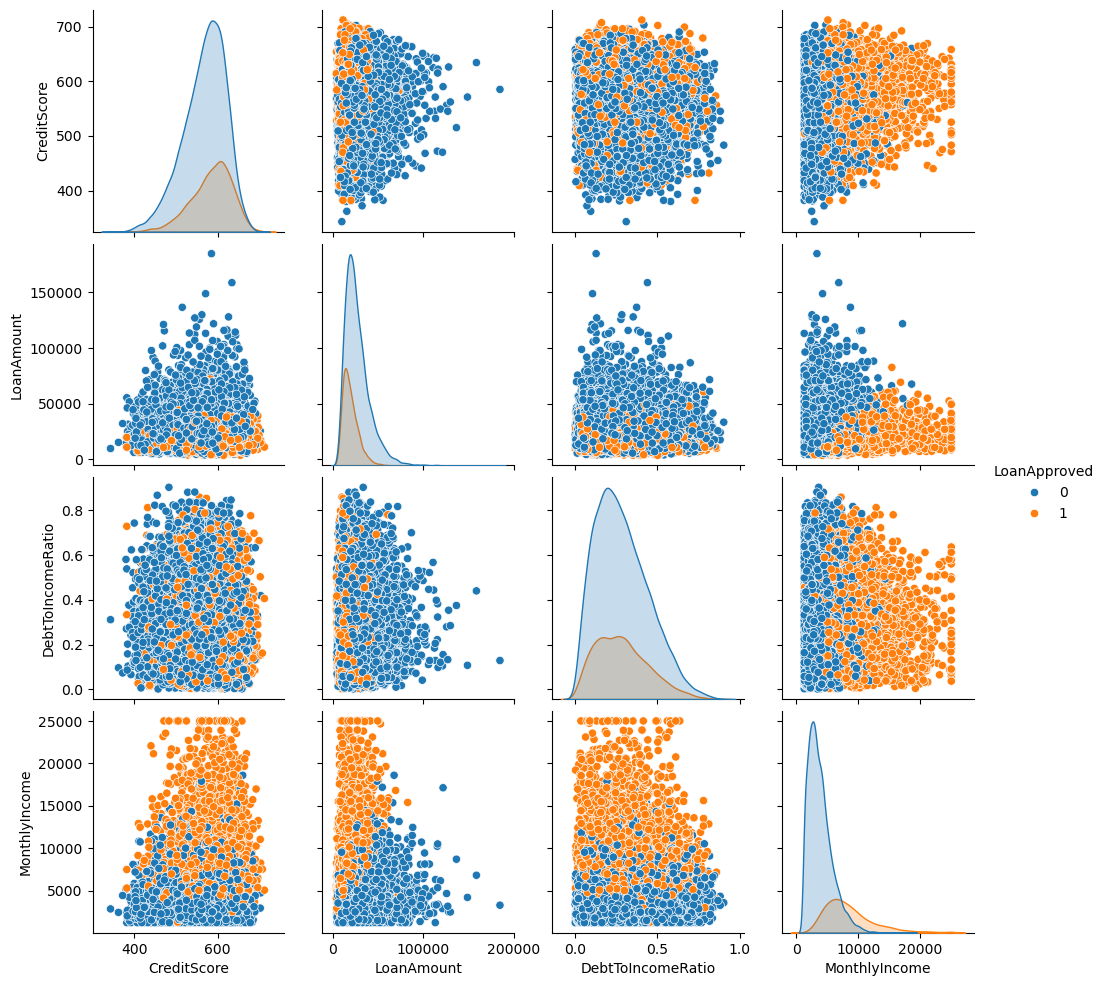

In [16]:
# Create a pair plot for selected numerical variables
pairplot_data = df[
    ["CreditScore", "LoanAmount", "DebtToIncomeRatio", "MonthlyIncome", "LoanApproved"]
].dropna()

sns.pairplot(
    pairplot_data,
    hue="LoanApproved"
)

plt.show()

### Pair Plot

The pair plot shows relationships between selected numerical variables and separates the observations by loan approval outcome. It helps identify patterns, relationships, and possible differences between approved and non-approved applications.


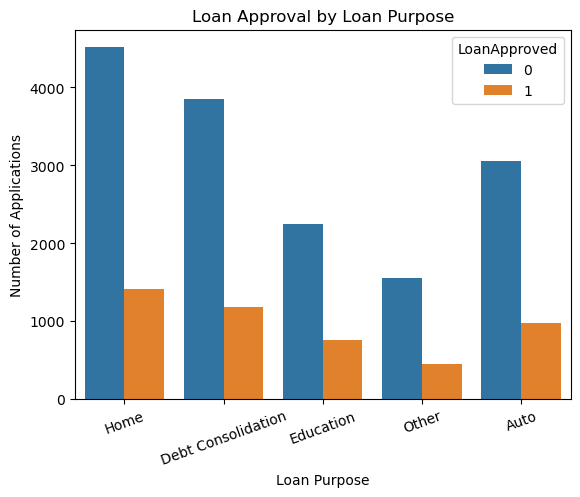

In [17]:
# Compare loan approval across loan purposes
sns.countplot(x="LoanPurpose", hue="LoanApproved", data=df)

plt.title("Loan Approval by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Number of Applications")
plt.xticks(rotation=20)
plt.show()

In [18]:
# Test whether credit scores differ between approved and non-approved applicants
from scipy.stats import ttest_ind

approved_credit = df[df["LoanApproved"] == 1]["CreditScore"]
not_approved_credit = df[df["LoanApproved"] == 0]["CreditScore"]

t_stat, p_value = ttest_ind(approved_credit, not_approved_credit)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 20.28645123644587
P-value: 1.3816662548784965e-90


---

## Data Preparation

### Preprocessing Strategy

Different types of features require different preprocessing steps. Numerical features will be handled separately from categorical features using a `ColumnTransformer`.

For numerical features, missing values will be filled using the median. The median is useful because it is less affected by unusually high or low values. Numerical features will also be standardized using `StandardScaler`, which is important for the Logistic Regression model because it helps put variables on a similar scale.

For categorical features, missing values will be filled using the most frequent value. Categorical variables will then be converted into numerical form using `OneHotEncoder`. `handle_unknown="ignore"` will be used so that the model can handle categories that appear in the test data but were not present in the training data.

The preprocessing steps will be placed inside a `Pipeline` and combined using `ColumnTransformer`. This keeps the preprocessing consistent between the training and test data and helps prevent data leakage.

The target variable `LoanApproved` will be kept separate from the input features. `RiskScore` will also be excluded because it represents a separate risk-related outcome and could provide information that would not be appropriate for predicting the approval decision.

An additional feature, `LoanToIncomeRatio`, will be created to represent the loan amount relative to the applicant's annual income. This may help the models understand the affordability of the requested loan.


### Clean Annual Income

`AnnualIncome` is currently stored as text because it contains dollar signs and commas. It needs to be converted to a numerical value so it can be used by the machine learning models.


In [20]:
# Data Prep Code Here - Create New Cells As Needed
# Convert AnnualIncome from text to a numerical value
df["AnnualIncome"] = (
    df["AnnualIncome"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

print(df["AnnualIncome"].dtype)

float64


### Feature Engineering

A `LoanToIncomeRatio` feature will be created to show the loan amount compared with the applicant's annual income. This can help the model understand how large the requested loan is relative to the applicant's income.


In [21]:
# Create a feature showing loan amount relative to annual income
df["LoanToIncomeRatio"] = df["LoanAmount"] / df["AnnualIncome"]

df[["LoanAmount", "AnnualIncome", "LoanToIncomeRatio"]].head()

,LoanAmount,AnnualIncome,LoanToIncomeRatio
0,13152,39948.0,0.329228
1,26045,39709.0,0.655897
2,17627,40724.0,0.432841
3,37898,69084.0,0.548579
4,9184,103264.0,0.088937


### Separate Target and Features

`LoanApproved` is the target variable because the goal is to predict whether a loan will be approved or not.

`RiskScore` will be excluded from the predictors because it represents a separate risk-related outcome and could provide information that would not be appropriate for predicting the original approval decision.


In [22]:
# Separate the target variable from the predictor variables
X = df.drop(columns=["LoanApproved", "RiskScore"])
y = df["LoanApproved"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (20000, 34)
Target: (20000,)


### Identify Feature Types

The predictor variables contain both numerical and categorical data. These feature types need different preprocessing steps.

Numerical features will be handled using imputation and scaling. Categorical features will be handled using imputation and one-hot encoding.


In [23]:
# Identify numerical and categorical features
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical features:", list(numeric_features))
print("Categorical features:", list(categorical_features))

Numerical features: ['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanToIncomeRatio']
Categorical features: ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']


### Numerical Feature Preprocessing

The numerical features will be processed in two steps. First, missing values will be replaced with the median value of the feature. This helps keep the data complete without being strongly affected by extreme values.

The numerical features will then be standardized using `StandardScaler`. Scaling is especially useful for Logistic Regression because the numerical features have different ranges. Tree-based models such as Decision Tree and Random Forest do not require scaling, but using the same preprocessing structure keeps the workflow consistent.


In [24]:
# Preprocessing pipeline for numerical features
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

### Categorical Preprocessing

Categorical columns contain words instead of numbers. Missing values will be replaced with the most common value, then the categories will be converted into numbers using one-hot encoding.


In [25]:
# Preprocessing pipeline for categorical features
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

### ColumnTransformer

`ColumnTransformer` lets us apply the right preprocessing to each type of feature. Numerical and categorical features will be processed separately.


In [26]:
# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


### Train-Test Split

The data will be split into training and testing sets. The training set will be used to build the models, while the test set will be used to check their performance.

Stratification will keep the same approval proportions in both sets.


In [27]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (16000, 34)
Testing set: (4000, 34)


---

## Modeling



### Modeling Approach

This is a classification problem because the target, `LoanApproved`, has two outcomes: approved or not approved.

Three models will be compared: Logistic Regression, Decision Tree, and Random Forest. Logistic Regression gives a simple baseline, while the tree-based models can capture more complex patterns.


In [28]:
#  Modeling Code Here - Create New Cells as Needed
# Create the three model pipelines

logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

forest_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

### Validation Strategy

The training data will be used for cross-validation, while the test data will only be used for final evaluation.

The main metrics will be precision, recall, F1-score, and ROC-AUC. These metrics are more useful than accuracy alone because the loan approval classes are imbalanced.


In [29]:
# Compare the three models using 5-fold cross-validation
models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": tree_pipeline,
    "Random Forest": forest_pipeline
}

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=5,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
        n_jobs=-1
    )
    
    print(name)
    print("Accuracy:", scores["test_accuracy"].mean())
    print("Precision:", scores["test_precision"].mean())
    print("Recall:", scores["test_recall"].mean())
    print("F1:", scores["test_f1"].mean())
    print("ROC-AUC:", scores["test_roc_auc"].mean())
    print()

Logistic Regression
Accuracy: 0.9634375000000001
Precision: 0.9283835396007069
Recall: 0.9178845429969543
F1: 0.9230875238630775
ROC-AUC: 0.9945080045870223

Decision Tree
Accuracy: 0.889875
Precision: 0.7635911041445674
Recall: 0.7813797351401293
F1: 0.7723334488658129
ROC-AUC: 0.8526640366896704

Random Forest
Accuracy: 0.9244375
Precision: 0.8748666095149092
Recall: 0.7981151832460732
F1: 0.834711802043077
ROC-AUC: 0.9754212645142847



### Cross-Validation Results

The three models produced different results during 5-fold cross-validation. Logistic Regression had the highest scores across the main evaluation metrics, while Random Forest also performed well. Decision Tree had lower scores across the metrics.

These results will be compared with the final test-set results after model tuning.


### Model Tuning

GridSearchCV will be used to test different Random Forest settings. A small parameter grid will be used to demonstrate the tuning process while keeping the training time reasonable.

The model will use 5-fold cross-validation and F1-score as the main tuning metric because it balances precision and recall.


In [30]:
# Define a small parameter grid for Random Forest
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, None],
    "model__min_samples_split": [2, 5]
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    forest_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Fit the grid search
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation F1:", grid_search.best_score_)

Best parameters: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best cross-validation F1: 0.8391602743581735


### Tuning Results

GridSearchCV tested different Random Forest settings using 5-fold cross-validation. The best configuration used 200 trees, no maximum depth limit, and a minimum of 5 samples required to split a node.

The best cross-validation F1-score was 0.8392. This shows how changing model settings can affect model performance.



In [31]:
# Use the best Random Forest model to make predictions
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Test predictions created.")

Test predictions created.


### Test Predictions

The tuned Random Forest model was used to predict loan approval on the test data. These predictions will now be compared with the actual outcomes to evaluate the model's performance on unseen data.


---

## Evaluation and Conclusion


### Test Data Performance

The tuned Random Forest will be evaluated on the test data using accuracy, precision, recall, F1-score, and ROC-AUC. These metrics show different aspects of the model's performance.


In [32]:
# Calculate test-set performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)

Accuracy: 0.93225
Precision: 0.8923253150057274
Recall: 0.8148535564853556
F1-score: 0.8518316019682887
ROC-AUC: 0.9781140552235277


### Confusion Matrix

The confusion matrix shows the model's correct and incorrect predictions for approved and not approved loans. It helps identify false positives and false negatives, which are important because they have different business costs.


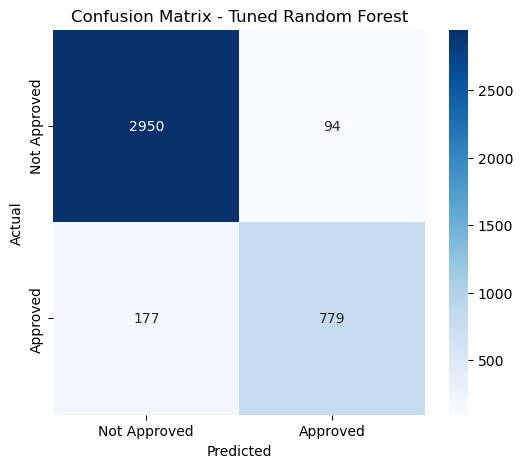

In [34]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Approved", "Approved"],
    yticklabels=["Not Approved", "Approved"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

### Business Impact

The business impact is calculated using the costs provided in the case. A false positive represents an approved loan that falls into the bad-loan cost category, while a false negative represents a creditworthy applicant whose loan was not approved. The estimated costs are $50,000 per false positive and $8,000 per false negative.


In [35]:
# Calculate business costs from the confusion matrix
tn, fp, fn, tp = cm.ravel()

false_positive_cost = fp * 50000
false_negative_cost = fn * 8000
total_cost = false_positive_cost + false_negative_cost

print("False Positives:", fp)
print("False Negatives:", fn)
print("Cost of approving bad loans: $", false_positive_cost)
print("Cost of denying good loans: $", false_negative_cost)
print("Total estimated cost: $", total_cost)

False Positives: 94
False Negatives: 177
Cost of approving bad loans: $ 4700000
Cost of denying good loans: $ 1416000
Total estimated cost: $ 6116000


### Feature Importance

Feature importance shows which input variables contributed most to the Random Forest's predictions. This helps identify the factors the model relied on most when predicting loan approval.


In [36]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
importances = best_model.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
27,num__LoanToIncomeRatio,0.161483
26,num__TotalDebtToIncomeRatio,0.148844
19,num__MonthlyIncome,0.122294
1,num__AnnualIncome,0.118239
24,num__InterestRate,0.076005
22,num__NetWorth,0.037111
17,num__TotalAssets,0.033640
4,num__LoanAmount,0.029697
23,num__BaseInterestRate,0.025848
25,num__MonthlyLoanPayment,0.023459


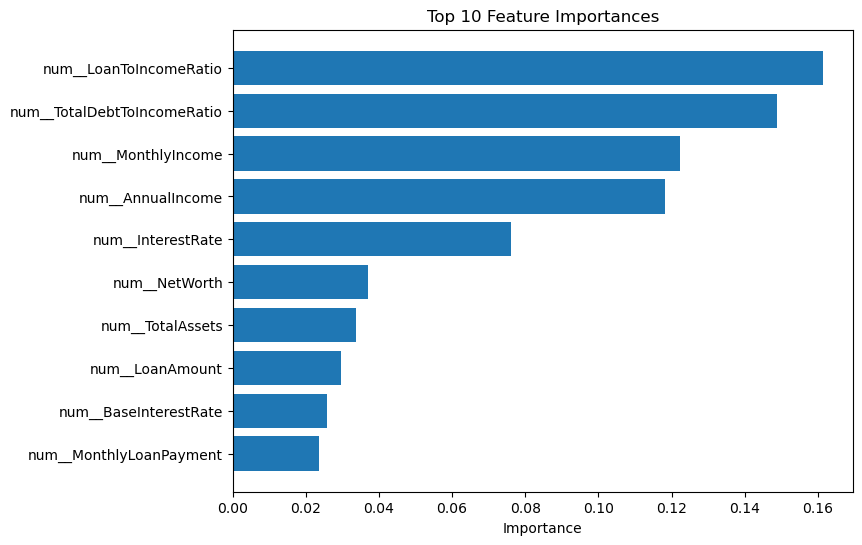

In [37]:
top_features = feature_importance.head(10).sort_values("Importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances")
plt.show()

### Segment Analysis

Model performance can vary across different applicant groups. Employment status and education level will be examined to compare actual approval rates, predicted approval rates, and prediction accuracy across segments.


In [38]:
segment_df = X_test.copy()
segment_df["Actual"] = y_test
segment_df["Predicted"] = y_pred
segment_df["Correct"] = segment_df["Actual"] == segment_df["Predicted"]

employment_results = segment_df.groupby("EmploymentStatus").agg(
    Applications=("Actual", "size"),
    Accuracy=("Correct", "mean"),
    Actual_Approval_Rate=("Actual", "mean"),
    Predicted_Approval_Rate=("Predicted", "mean")
)

employment_results

,Applications,Accuracy,Actual_Approval_Rate,Predicted_Approval_Rate
EmploymentStatus,,,,
Employed,3402,0.934156,0.242210,0.216931
Self-Employed,311,0.926045,0.263666,0.221865
Unemployed,287,0.916376,0.174216,0.229965


In [39]:
education_results = segment_df.groupby("EducationLevel").agg(
    Applications=("Actual", "size"),
    Accuracy=("Correct", "mean"),
    Actual_Approval_Rate=("Actual", "mean"),
    Predicted_Approval_Rate=("Predicted", "mean")
)

education_results

,Applications,Accuracy,Actual_Approval_Rate,Predicted_Approval_Rate
EducationLevel,,,,
Associate,782,0.930946,0.207161,0.194373
Bachelor,1163,0.927773,0.279450,0.250215
Doctorate,156,0.891026,0.442308,0.371795
High School,1086,0.954880,0.152855,0.159300
Master,620,0.900000,0.377419,0.312903


### ROC Curve

The ROC curve shows how well the model separates approved and not approved loans at different probability thresholds. The ROC-AUC summarizes this performance, with values closer to 1 showing stronger separation between the two classes.


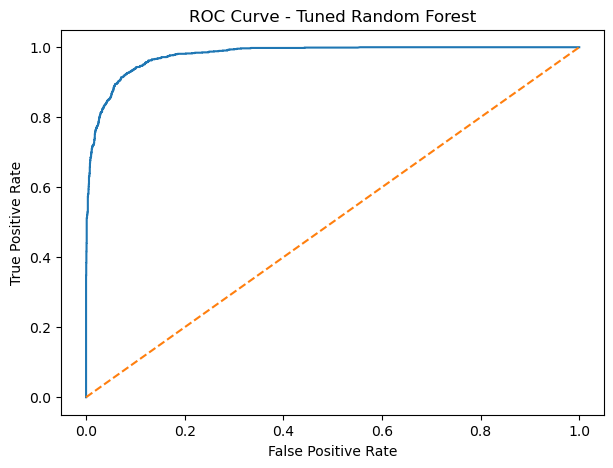

In [40]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Random Forest")
plt.show()

### Bias and Limitations

The dataset has an imbalanced target, with more applications being not approved than approved. Although preprocessing and evaluation were used to reduce the impact of this imbalance, it can still affect model performance.

Missing values were handled using imputation, but the fact that information was missing may itself contain useful information that the model does not explicitly capture.

The dataset may not fully represent real-world loan applicants because it is a prepared dataset. In addition, the target records historical approval decisions rather than actual loan repayment or default outcomes. This means the model learns patterns in previous approval decisions and does not directly predict whether a borrower will default.

The business cost analysis is therefore an estimate based on the costs provided in the case. Before using the model in a real lending environment, it would be important to validate it using actual repayment and default outcomes, monitor performance across applicant groups, and check for changes in data over time.


### Conclusion

The tuned Random Forest achieved 93.23% accuracy, 89.23% precision, 81.49% recall, 85.18% F1-score, and 97.81% ROC-AUC on the test data. The model produced 94 false positives and 177 false negatives, giving an estimated business cost of $6,116,000 under the case assumptions.

The most important features were LoanToIncomeRatio, TotalDebtToIncomeRatio, MonthlyIncome, and AnnualIncome.

The model shows strong predictive performance, but it should be tested with real repayment and default data before being used for actual loan decisions.


### Test Model Comparison

The three classification models will be compared on the test data using the same evaluation metrics. This helps assess how each model performs on unseen data.


In [41]:
test_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    
    test_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

test_results_df = pd.DataFrame(test_results)
test_results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.96575,0.931507,0.924686,0.928084,0.994581
1,Decision Tree,0.89175,0.785169,0.753138,0.768820,0.844210
2,Random Forest,0.93025,0.886857,0.811715,0.847624,0.978091
